# Individual Plot Examples
This notebook demonstrates how to create individual visualizations using the updated SubSketch plotting functions.

In [27]:
from IPython.display import SVG, display
from pathlib import Path

from subsketch.io import read_detected_motifs, read_motifs, read_domain_hits, read_compounds
from subsketch.loaders import load_bgc, load_domain_colors
from subsketch.draw.bgc import draw_bgc, draw_subcluster_hit
from subsketch.draw.motif import plot_subcluster_motif
from subsketch.draw.molecule import draw_compounds, draw_compounds_with_substruct_flexible


## Load Data
Load the necessary data files for visualization

In [28]:
from importlib.resources import files

example_data_dir = Path("./example_data/")


# Load domain hits, motifs, and compounds
domain_hits = read_domain_hits(example_data_dir / "mibig_4.0_domain_hits.txt")
bgc2hits, motif2hits = read_detected_motifs(example_data_dir / "mibig_4.0_detected_motifs.tsv")
motifs = read_motifs(example_data_dir / "clusterclue_motifs.txt")
compounds = read_compounds(example_data_dir / "mibig_4.0_compounds.tsv")
domain_colors = load_domain_colors(Path(files("subsketch").joinpath("data")).joinpath("domain_colors.txt"))

print(f"Loaded {len(domain_hits)} BGCs with domain hits")
print(f"Loaded {len(motifs)} motifs")
print(f"Loaded {len(compounds)} BGCs with compound information")

Loaded 2624 BGCs with domain hits
Loaded 1093 motifs
Loaded 2116 BGCs with compound information


## Visualise a BGC

In [29]:
# Select a BGC ID (e.g., one with motif hits)
bgc_id = "BGC0000893"  # Change this to any BGC ID you want to visualize

# Load the BGC data
bgc_gbk_path = example_data_dir / "mibig_4.0_gbks" / f"{bgc_id}.gbk"
bgc_data = load_bgc(bgc_gbk_path)

print(f"Loaded BGC: {bgc_data['id']}")
print(f"Length: {bgc_data['length']} bp")
print(f"Number of CDS features: {len(bgc_data['cds_features'])}")

Loaded BGC: BGC0000893
Length: 22006 bp
Number of CDS features: 17


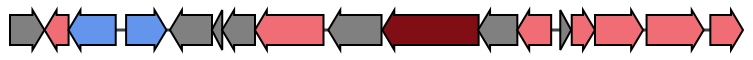

In [30]:
bgc_svgstr = draw_bgc(
    bgc_data,
    color_genes=True,  # Color by antiSMASH gene type
    scaling=30,  # Adjust for visualization size
)
display(SVG(bgc_svgstr))

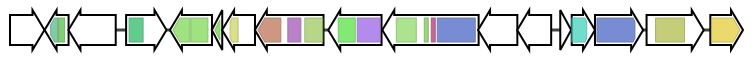

In [31]:
bgc_svg = draw_bgc(
    bgc_data=bgc_data,
    bgc_domain_hits=domain_hits.get(bgc_id, {}),
    domain_colors=domain_colors,
    color_genes=False,  # Dont color by antiSMASH gene type
    color_domains=True,  # Show colored domains
    scaling=30,  # Adjust for visualization size
)

display(SVG(bgc_svg))

## Visualize Motif Hit in BGC
Highlight genes that match a detected subcluster motif

Motif ID: M1181
Score: 21.143
Matching genes: CM_2, DAHP_synth_2_c8;DAHP_synth_2_c2, GATase_c6;Anth_synt_I_N;Chorismate_bind_c2


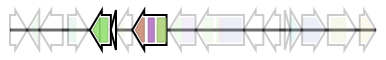

In [32]:
# Check if this BGC has any motif hits
if bgc_id in bgc2hits and len(bgc2hits[bgc_id]) > 0:
    # Select a motif hit for this BGC
    hit = bgc2hits[bgc_id][1]
    
    print(f"Motif ID: {hit['motif_id']}")
    print(f"Score: {hit['score']}")
    print(f"Matching genes: {', '.join(hit['genes'])}")
    
    # Draw BGC with motif hit highlighted
    motif_bgc_svg = draw_subcluster_hit(
        bgc_data=bgc_data,
        bgc_domain_hits=domain_hits.get(bgc_id, {}),
        domain_colors=domain_colors,
        motif_hit=hit,
        color_genes=False,  # Use domain colors instead
        scaling=60,
    )
    
    display(SVG(motif_bgc_svg))
else:
    print(f"No motif hits found for {bgc_id}")
    print("Try a different BGC ID with motif hits")

## Visualize Motif Pattern
Display the subcluster motif weight matrix with highlighted matching genes

Visualizing motif: M1181
Genes in motif: DAHP_synth_2_c8;DAHP_synth_2_c2, GATase_c6;Anth_synt_I_N;Chorismate_bind_c2, Aminotran_4, CM_2
Detection threshold: 14.129


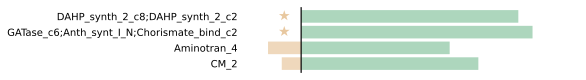

In [33]:
# Select a motif ID to visualize
motif_id = "M1181"
motif = motifs[motif_id]

print(f"Visualizing motif: {motif_id}")
print(f"Genes in motif: {', '.join(motif.tokenized_genes)}")
print(f"Detection threshold: {motif.threshold}")

# Plot motif without hit highlighting
motif_svg = plot_subcluster_motif(
    motif=motif,
    hit=None,  # No hit to highlight
    add_title=False,
    scaling=1.0,
)

display(SVG(motif_svg))

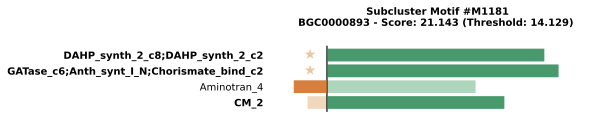

In [34]:
# highlight the genes present in the motif hit

motif_id = "M1181"
motif = motifs[motif_id]
hit = motif2hits[motif_id][0]

motif_svg = plot_subcluster_motif(
    motif,
    hit,
    add_title=True,
)
display(SVG(motif_svg))

## Visualize Compounds
Display chemical structures associated with a BGC

Found 1 compound(s) for BGC0000893
  - chloramphenicol: OCC(NC(=O)C(Cl)Cl)C(O)C1=CC=C(C=C1)N(=O)=O


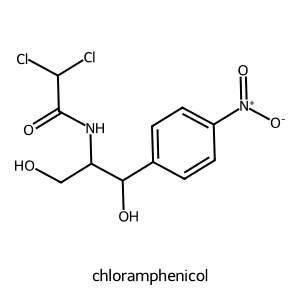

In [35]:
# Check if this BGC has compound information
if bgc_id in compounds and len(compounds[bgc_id]) > 0:
    bgc_compounds = compounds[bgc_id]
    
    print(f"Found {len(bgc_compounds)} compound(s) for {bgc_id}")
    for name, smiles in bgc_compounds:
        print(f"  - {name}: {smiles[:50]}..." if len(smiles) > 50 else f"  - {name}: {smiles}")
    
    # Draw compounds
    compounds_svg = draw_compounds(
        compounds=bgc_compounds,
        show_names=True,
        scaling=1.5,
    )
    
    display(SVG(compounds_svg))
else:
    print(f"No compound information found for {bgc_id}")
    print("Try a different BGC ID or check the compounds.tsv file")

Highlighting substructure: c1ccccc1


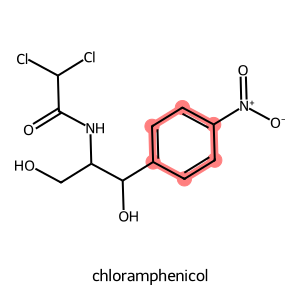

In [36]:
# Define a substructure to highlight (SMILES pattern)
substruct_smiles = "c1ccccc1"

if bgc_id in compounds and len(compounds[bgc_id]) > 0:
    bgc_compounds = compounds[bgc_id]
    
    print(f"Highlighting substructure: {substruct_smiles}")
    
    # Draw compounds with substructure highlighting
    compounds_svg = draw_compounds_with_substruct_flexible(
        compounds=bgc_compounds,
        substruct_smiles=substruct_smiles,
        show_names=True,
        scaling=1.5,
    )
    
    display(SVG(compounds_svg))
else:
    print(f"No compound information found for {bgc_id}")